<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week04-feature-scaling/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: 특성 스케일링과 학습 곡선

##  핵심 개념
- **feature scaling( Min-max, Mean, Z-score)**

- **Gradient Descent on polynomial regression**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 두 특성의 스케일을 일부러 크게 다르게 만든다
# 특성1 = size(집 크기): 수백~수천 단위 / 특성2 = bedrooms(침실 수): 한 자릿수

X_train = np.array([
    [2104, 5],
    [1416, 3],
    [1534, 3],
    [852, 2],
], dtype = float)     # shape: (4, 2) → 데이터 4개, 특성 2개

# 정답값(집 가격, 천 달러 단위) — 정규화하지 않은 값
y_train = np.array([460, 232, 315, 178], dtype=float)

# 두 특성의 값 범위를 직접 확인
print("size 범위:", X_train[:, 0].min(), "~", X_train[:, 0].max())
print("bedrooms 범위:", X_train[:, 1].min(), "~", X_train[:, 1].max())

size 범위: 852.0 ~ 2104.0
bedrooms 범위: 2.0 ~ 5.0


In [ ]:
# 특성마다 평균과 표준편차를 계산
# axis = 0 -> 열(특성) 방향으로 계산
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

# Z-score : (값 - 평균) / 표준편차
X_norm = (X_train - mu) / sigma

print("평균(mu):", mu)
print("표준편차(sigma):", np.round(sigma, 3))
print("정규화 결과:\n", np.round(X_norm, 3))

평균(mu): [1476.5     3.25]
표준편차(sigma): [444.613   1.09 ]
정규화 결과:
 [[ 1.411  1.606]
 [-0.136 -0.229]
 [ 0.129 -0.229]
 [-1.405 -1.147]]


In [ ]:
from sklearn.preprocessing import StandardScaler

# StandardScaler : Z-score 정규화를 해주는 도구
scaler = StandardScaler()
X_norm_sklearn = scaler.fit_transform(X_train)

print("직접 구현 :\n", np.round(X_norm, 3))
print("sklearn :\n", np.round(X_norm_sklearn, 3))
print("두 결과가 거의 같은가?", np.allclose(X_norm, X_norm_sklearn))

직접 구현 :
 [[ 1.411  1.606]
 [-0.136 -0.229]
 [ 0.129 -0.229]
 [-1.405 -1.147]]
sklearn :
 [[ 1.411  1.606]
 [-0.136 -0.229]
 [ 0.129 -0.229]
 [-1.405 -1.147]]
두 결과가 거의 같은가? True


In [ ]:
#  비용함수(MSE)
def compute_cost(X, y, w, b):
  m = X.shape[0]
  f_wb = X @ w + b
  return np.sum((f_wb - y) ** 2) / (2 * m)

# 기울기 계산
def compute_gradient(X, y, w, b):
  m = X.shape[0]
  error = (X @ w + b) - y
  dj_dw = (X.T @ error) / m
  dj_db = np.sum(error) / m
  return dj_dw, dj_db

# 경사하강법
def gradient_descent(X, y, w, b, alpha, iters):
  cost_history = []
  for i in range(iters):
    dj_dw, dj_db = compute_gradient(X, y, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    cost_history.append(compute_cost(X, y, w, b))
  return w, b, cost_history

정규화 X -> 최종 비용: 524.3
정규화 X + 큰 학습률 → 최종 비용: 4.0481120833955133e+18
정규화 O -> 최종 비용: 359.26


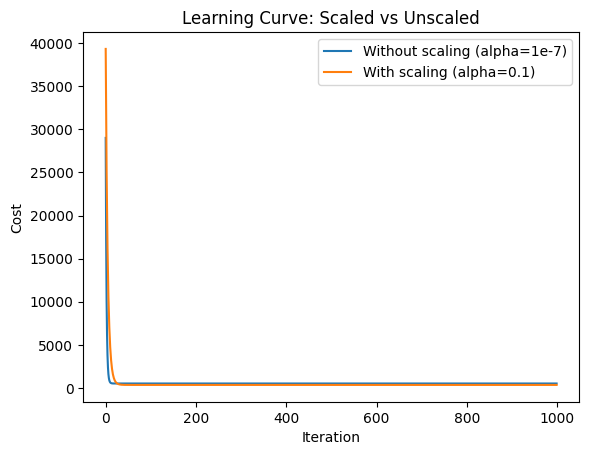

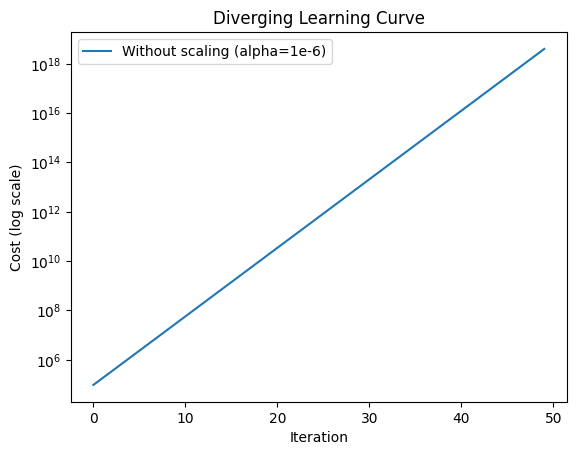

In [ ]:
# 초기 파라미터: 가중치 0, 편향 0에서 시작
w_init = np.zeros(X_train.shape[1])
b_init = 0.0

# 정규화 안한 데이터 -> 스케일이 커서 학습률을 아주 작게줘야한다
_, _, cost_raw = gradient_descent(X_train, y_train, w_init, b_init, alpha = 1e-7, iters = 1000)
# 정규화 안한 데이터 -> 학습률 크게 주고 발산
_, _, cost_diverge = gradient_descent(X_train, y_train, w_init, b_init, alpha = 1e-6, iters = 50)
# 정규화한 데이터 -> 학습률을 훨신 크게 설정 가능
_, _, cost_norm = gradient_descent(X_norm, y_train, w_init, b_init, alpha = 0.1, iters = 1000)

print("정규화 X -> 최종 비용:", round(cost_raw[-1], 2))
print("정규화 X + 큰 학습률 → 최종 비용:", cost_diverge[-1])
print("정규화 O -> 최종 비용:", round(cost_norm[-1],2))

# 두 학습 곡선(learning curve) 비교
plt.plot(cost_raw, label="Without scaling (alpha=1e-7)")
plt.plot(cost_norm, label="With scaling (alpha=0.1)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Curve: Scaled vs Unscaled")
plt.legend()
plt.show()

plt.plot(cost_diverge, label="Without scaling (alpha=1e-6)")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost (log scale)")
plt.title("Diverging Learning Curve")
plt.legend()
plt.show()